# Exploratory Data Analysis
This notebook focus on exploratory data analysis

Import libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

Load & Inspect data

In [34]:
df = pd.read_csv(r'C:\PlantNxt Assignment\data\processed\data.csv')
df.head()

,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others
0,Account A,Cust-00762,Part-01473,2022-04-01,3.0,9787.10,8415.52,694.14
1,Account A,Cust-00762,Part-01473,2022-04-01,10.0,9787.10,28051.74,2313.80
2,Account A,Cust-00519,Part-01675,2022-04-01,18.6,46045.00,154158.66,10105.96
3,Account A,Cust-00302,Part-01312,2022-04-01,5.0,4761.14,4570.44,1585.65
4,Account A,Cust-00302,Part-01573,2022-04-01,5.0,4752.34,4562.52,1585.65


In [35]:
df.tail()

,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others
200233,Account B,Cust-00265,Part-00241,2026-05-16,180.0,327.62,7707.959666,0.0
200234,Account B,Cust-00320,Part-00215,2026-05-16,596.5,242.86,7707.959666,0.0
200235,Account B,Cust-00320,Part-00215,2026-05-16,1800.0,315.86,7707.959666,0.0
200236,Account B,Cust-00233,Part-00138,2026-05-16,3000.0,299.25,7707.959666,0.0
200237,Account B,Cust-00630,Part-00289,2026-05-16,2400.0,332.33,7707.959666,0.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200238 entries, 0 to 200237
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Account    200238 non-null  object 
 1   Cust Code  200238 non-null  object 
 2   Part Code  200238 non-null  object 
 3   Inv Date   200238 non-null  object 
 4   Quantity   200238 non-null  float64
 5   Price      200238 non-null  float64
 6   Tax        200238 non-null  float64
 7   Others     200238 non-null  float64
dtypes: float64(4), object(4)
memory usage: 12.2+ MB


In [37]:
df.describe()

,Quantity,Price,Tax,Others
count,200238.000000,2.002380e+05,200238.000000,200238.000000
mean,278.901088,2.850676e+03,7890.062783,1032.341430
std,1580.161627,3.819176e+04,12714.777133,1634.441397
min,-69150.000000,-4.150000e+06,-747000.000000,-7450.850000
25%,10.300000,2.413600e+02,2410.020000,0.000000
50%,40.000000,5.688000e+02,5580.720000,329.425000
75%,120.000000,3.314060e+03,8652.380000,1494.960000
max,158025.000000,4.335095e+06,780317.020000,112245.180000


In [38]:
# convert datatype of date column to dateformat 
df['Inv Date'] = pd.to_datetime(df['Inv Date'])

Add relevant features

In [39]:
df['Revenue'] = df['Quantity'] * df['Price']

df['day_name']    = df['Inv Date'].dt.day_name()       
df['day_of_week'] = df['Inv Date'].dt.dayofweek       
df['week_number'] = df['Inv Date'].dt.isocalendar().week.astype(int)  
df['month']       = df['Inv Date'].dt.month           
df['month_name']  = df['Inv Date'].dt.month_name()     
df['quarter']     = df['Inv Date'].dt.quarter        
df['year']        = df['Inv Date'].dt.year             
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int) 

In [40]:
df.head(2)

,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others,Revenue,day_name,day_of_week,week_number,month,month_name,quarter,year,is_weekend
0,Account A,Cust-00762,Part-01473,2022-04-01,3.0,9787.1,8415.52,694.14,29361.3,Friday,4,13,4,April,2,2022,0
1,Account A,Cust-00762,Part-01473,2022-04-01,10.0,9787.1,28051.74,2313.80,97871.0,Friday,4,13,4,April,2,2022,0


Outlier check

In [41]:
Q1 = df['Revenue'].quantile(0.01)
Q99 = df['Revenue'].quantile(0.99)
print(f"1st pct: {Q1:,.0f}, 99th pct: {Q99:,.0f}")
outliers = df[(df['Revenue'] < Q1) | (df['Revenue'] > Q99)]
print(f"Outlier rows: {len(outliers)}")

1st pct: 319, 99th pct: 826,094
Outlier rows: 3946


### Revenue by Accounts

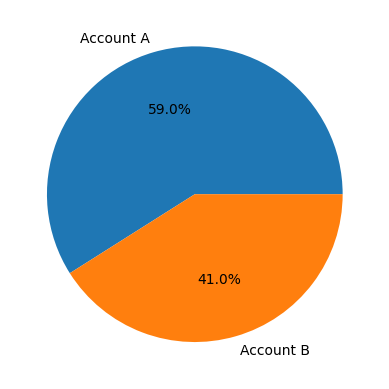

In [42]:
revenue_by_accnt = df.groupby('Account')['Revenue'].sum()
plt.pie(revenue_by_accnt.values, labels = revenue_by_accnt.index, autopct='%1.1f%%')
plt.show()

### Revenue Trend over Time

Yearly Revenue Trend

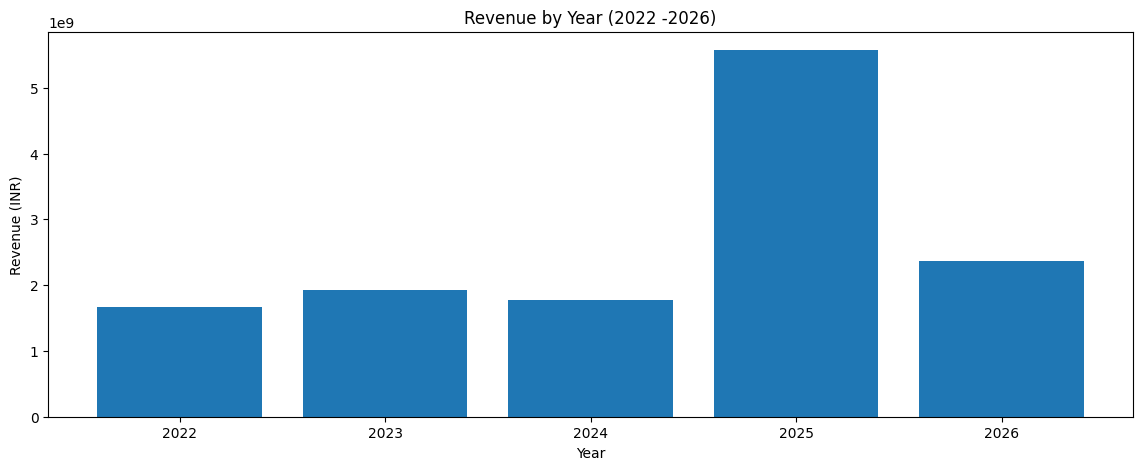

In [44]:
yearly = df.groupby('year')['Revenue'].sum()

plt.figure(figsize=(14, 5))
plt.bar(yearly.index, yearly.values)
plt.title('Revenue by Year (2022 -2026)')
plt.xlabel('Year')
plt.ylabel('Revenue (INR)')
plt.show()

Daily Revenue Trend

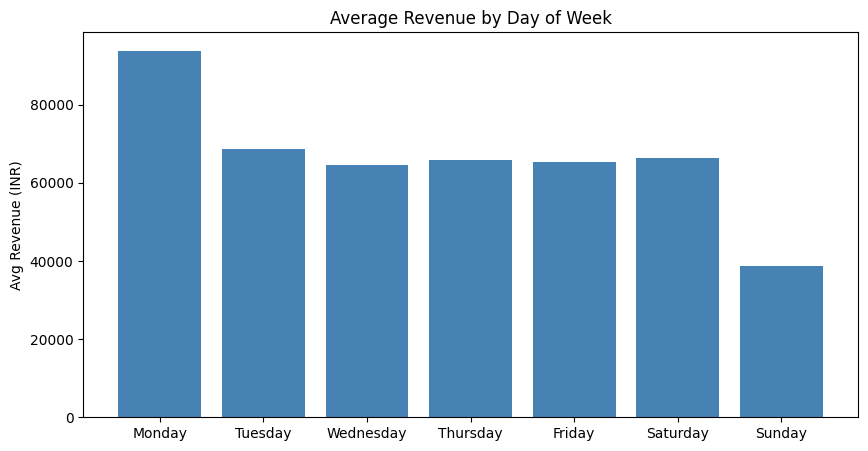

In [ ]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = df.groupby('day_name')['Revenue'].mean().reindex(dow_order)

plt.figure(figsize=(10, 5))
plt.bar(dow_avg.index, dow_avg.values, color='steelblue')
plt.title('Average Revenue by Day of Week')
plt.ylabel('Avg Revenue (INR)')
plt.show()

Weekly Revenue Trend

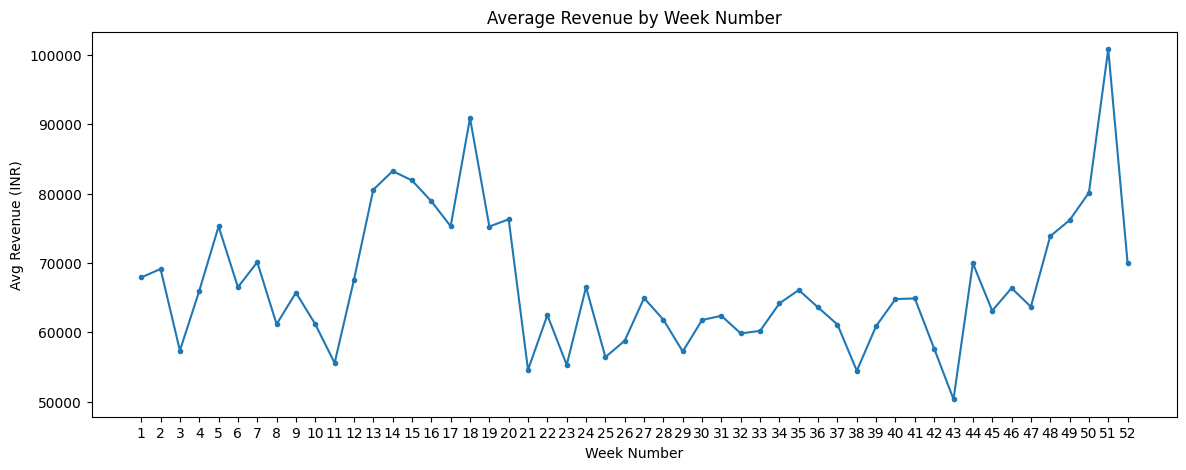

In [ ]:
week_avg = df.groupby('week_number')['Revenue'].mean()

plt.figure(figsize=(14, 5))
plt.plot(week_avg.index, week_avg.values, marker='o', markersize=3)
plt.title('Average Revenue by Week Number')
plt.xlabel('Week Number')
plt.ylabel('Avg Revenue (INR)')
plt.xticks(range(1, 53))
plt.show()

Monthly Revenue Trend

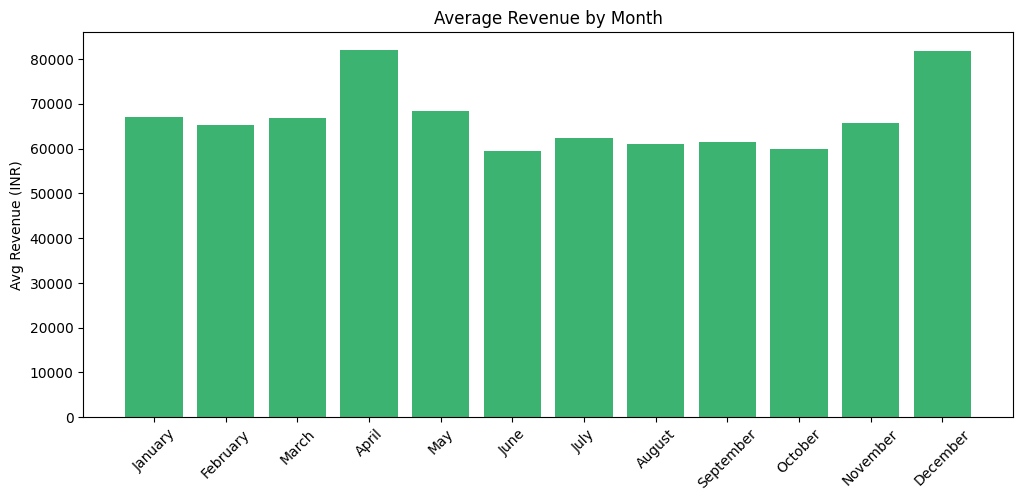

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_avg = df.groupby('month_name')['Revenue'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.bar(month_avg.index, month_avg.values, color='mediumseagreen')
plt.title('Average Revenue by Month')
plt.ylabel('Avg Revenue (INR)')
plt.xticks(rotation=45)
plt.show()

By part

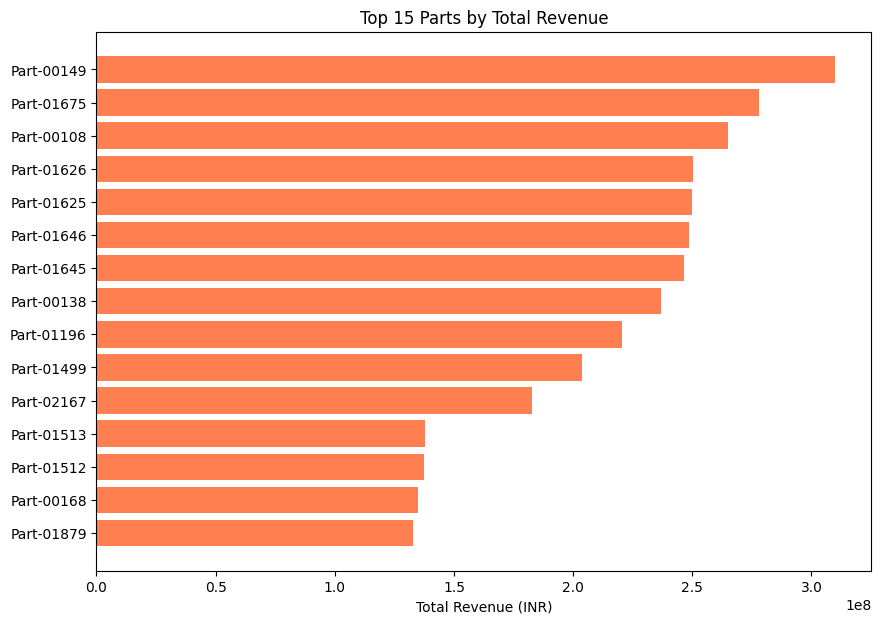

In [ ]:
part_revenue = df.groupby('Part Code')['Revenue'].sum().nlargest(15).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(part_revenue.index, part_revenue.values, color='coral')
plt.title('Top 15 Parts by Total Revenue')
plt.xlabel('Total Revenue (INR)')
plt.show()

Decomposition Visualization

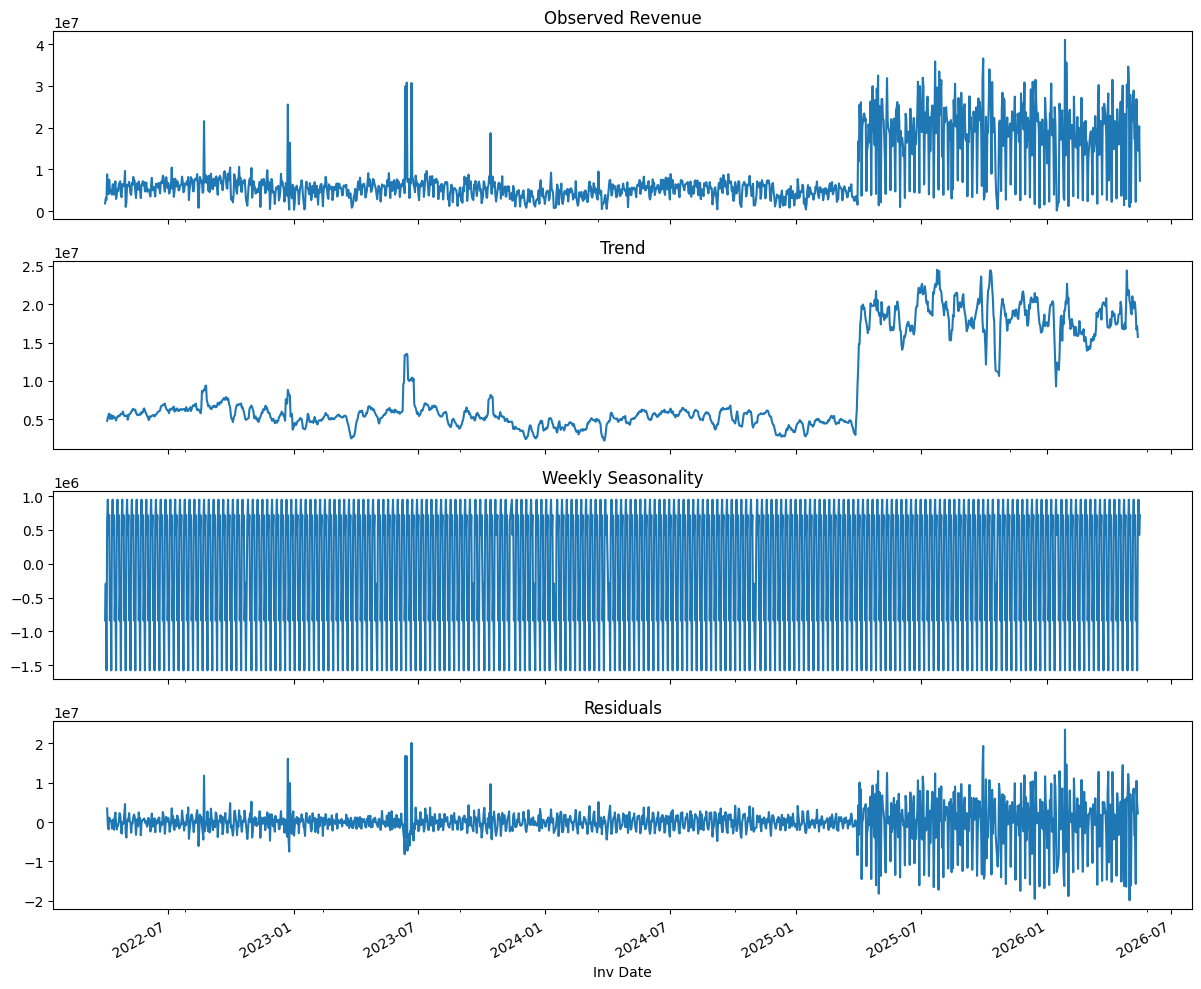

In [ ]:
daily_data = df.groupby('Inv Date')['Revenue'].sum().reset_index()
daily_data['Inv Date'] = pd.to_datetime(daily_data['Inv Date'])
daily_data = daily_data.set_index('Inv Date')
decomp = seasonal_decompose(daily_data['Revenue'], model='additive', period=7) 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True) 
decomp.observed.plot(ax=ax1, title='Observed Revenue') 
decomp.trend.plot(ax=ax2, title='Trend') 
decomp.seasonal.plot(ax=ax3, title='Weekly Seasonality') 
decomp.resid.plot(ax=ax4, title='Residuals') 
plt.tight_layout() 
plt.show()

### Insights

1. Revenue disitribution by account
    - Account A is the primary contributor, accounting for roughly 59% of the total revenue.
    - Account B contributes the remaining 41%.
2. Yearly revenue trends
    - 2022-2024: Revenue remained relatively stable, ranging between 1.6B and 1.9B INR.
    - 2025: There was an exceptional peak in revenue, reaching over 5.5B INR, which is more than triple the average of previous years.
    - 2026 (YTD): Revenue for the first few months of 2026 is already at 2.37B INR, suggesting that 2026 might even surpass the record set in 2025.

3. Product level performance
    - Part-00149 is the highest-performing item, contributing approximately 301 Million INR to the total revenue.
    - The "Top 15 Parts" chart highlights that a small fraction of parts is responsible for a significant portion of the total earnings.

4. Trend over time
    1. Monthly trend
        - Peak 1: April has the highest average revenue and a very high transaction volume. May follows closely with high total revenue.
        Reason: Financial Year Beginning: In India, the new financial year starts on April 1st. Companies often start new projects, release new budgets.
        April and May are the hottest months in India. If these parts are related to cooling (HVAC), automobiles (travel), or infrastructure, demand spikes as maintenance and consumption rise before the monsoon hits.

        - Peak 2: December shows a massive spike in average transaction value and January remains strong.
        Reason: Year-End Closing: Multinational corporations (MNCs) often follow the calendar year
           
        - Moderate: Revenue and transaction counts remain moderate but don't hit the peaks of April or December.
        Reason: The Southwest Monsoon covers India during these months. Heavy rains often slow down construction, logistics, and infrastructure projects, leading to a temporary stabilization or dip in industrial demand.
    2. Weekly trend
        - Week 51 & 50	December: Pre-Christmas & Year-End: High-value procurement and holiday-related logistics peaks.
        - Week 14, 15, 16, 17, 18  April:	New Financial Year Kick-off: This is the most consistent high-revenue period. The first 3 weeks of April show high "bulk" buying as new annual contracts or budgets are activated.
        - Week 43 (Late October): This is consistently your lowest-performing week.
